In [1]:
import sys
sys.path.append("../src")

import time
import copy

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import models

from dataset import (
    gather_samples, stratified_split, compute_class_weights,
    RiceLeafDataset, CLASSES
)

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [3]:
samples = gather_samples()
train_set, val_set, test_set = stratified_split(samples)
print("Train:", len(train_set), "Val:", len(val_set), "Test:", len(test_set))

class_weights = compute_class_weights(train_set)
class_weights_t = torch.tensor(class_weights, dtype=torch.float32).to(device)
print("Class weights:", class_weights)

Train: 1927 Val: 413 Test: 413
Class weights: [0.6523358 1.3973894 0.9331719 0.5652684 1.591247  1.4800308 1.6484175]


In [4]:
BATCH_SIZE = 32
NUM_WORKERS = 4

train_ds = RiceLeafDataset(train_set, split="train")
val_ds = RiceLeafDataset(val_set, split="val")
test_ds = RiceLeafDataset(test_set, split="test")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print("Batches - train/val/test:", len(train_loader), len(val_loader), len(test_loader))

Batches - train/val/test: 61 13 13


In [5]:
NUM_CLASSES = len(CLASSES)

model = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.IMAGENET1K_V2)
model.classifier[3] = nn.Linear(model.classifier[3].in_features, NUM_CLASSES)
model = model.to(device)

print(model.classifier)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /home/jaimul/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:05<00:00, 4.18MB/s]


Sequential(
  (0): Linear(in_features=960, out_features=1280, bias=True)
  (1): Hardswish()
  (2): Dropout(p=0.2, inplace=True)
  (3): Linear(in_features=1280, out_features=7, bias=True)
)


In [6]:
criterion = nn.CrossEntropyLoss(weight=class_weights_t)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

NUM_EPOCHS = 30
PATIENCE = 7

In [9]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * imgs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total

In [10]:
best_val_loss = float("inf")
best_model_wts = copy.deepcopy(model.state_dict())
epochs_no_improve = 0
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(NUM_EPOCHS):
    start = time.time()
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    elapsed = time.time() - start
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | "
          f"time={elapsed:.1f}s")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
        torch.save(best_model_wts, "mobilenetv3_large_best.pth")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

model.load_state_dict(best_model_wts)
print("Best val_loss:", best_val_loss)

Epoch 1/30 | train_loss=1.7414 train_acc=0.3197 | val_loss=1.8633 val_acc=0.3245 | time=27.4s
Epoch 2/30 | train_loss=1.1960 train_acc=0.5874 | val_loss=1.5153 val_acc=0.5109 | time=24.3s
Epoch 3/30 | train_loss=0.9082 train_acc=0.6860 | val_loss=1.1950 val_acc=0.5981 | time=28.3s
Epoch 4/30 | train_loss=0.7932 train_acc=0.7239 | val_loss=0.9105 val_acc=0.7094 | time=26.7s
Epoch 5/30 | train_loss=0.7154 train_acc=0.7509 | val_loss=0.9134 val_acc=0.7337 | time=27.0s
Epoch 6/30 | train_loss=0.6083 train_acc=0.7872 | val_loss=0.8609 val_acc=0.7191 | time=23.3s
Epoch 7/30 | train_loss=0.5692 train_acc=0.8038 | val_loss=0.8452 val_acc=0.7191 | time=27.1s
Epoch 8/30 | train_loss=0.5543 train_acc=0.8184 | val_loss=0.7953 val_acc=0.7337 | time=27.2s
Epoch 9/30 | train_loss=0.4720 train_acc=0.8256 | val_loss=0.8913 val_acc=0.7482 | time=28.8s
Epoch 10/30 | train_loss=0.4416 train_acc=0.8391 | val_loss=0.8113 val_acc=0.7264 | time=25.4s
Epoch 11/30 | train_loss=0.3853 train_acc=0.8594 | val_loss

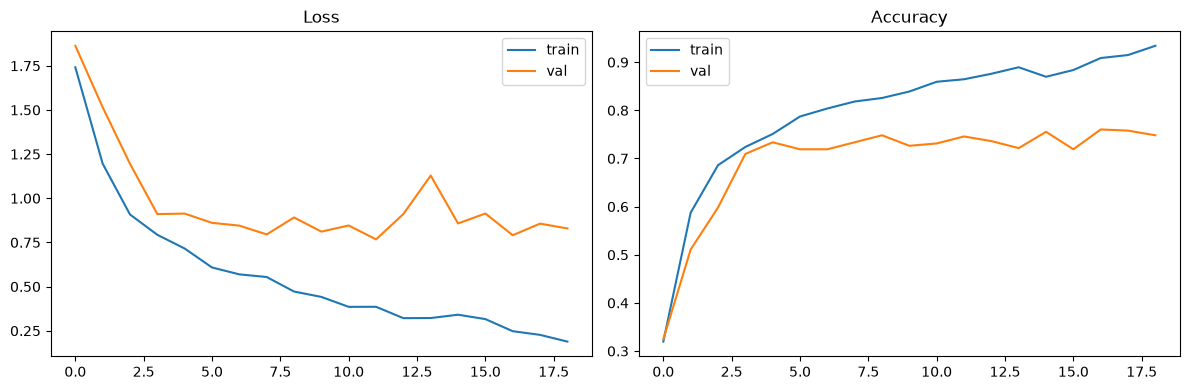

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="val")
axes[1].set_title("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

In [12]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score

model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print("Macro-F1:", f1_score(all_labels, all_preds, average="macro"))
print(classification_report(all_labels, all_preds, target_names=CLASSES))
print("Confusion matrix:\n", confusion_matrix(all_labels, all_preds))

Macro-F1: 0.7233703514866284
                 precision    recall  f1-score   support

        Healthy       0.86      0.86      0.86        90
         Insect       0.81      0.83      0.82        42
     Leaf Scald       0.77      0.68      0.72        63
     Rice Blast       0.87      0.78      0.82       105
Rice Leaffolder       0.69      0.78      0.73        37
   Rice Stripes       0.47      0.57      0.52        40
    Rice Tungro       0.56      0.61      0.59        36

       accuracy                           0.75       413
      macro avg       0.72      0.73      0.72       413
   weighted avg       0.76      0.75      0.76       413

Confusion matrix:
 [[77  3  0  3  0  2  5]
 [ 0 35  3  2  2  0  0]
 [ 0  0 43  1  8  9  2]
 [ 7  1  2 82  1  4  8]
 [ 2  1  1  1 29  3  0]
 [ 1  2  6  4  2 23  2]
 [ 3  1  1  1  0  8 22]]


In [13]:
import time as _time

num_params = sum(p.numel() for p in model.parameters())
print("Total params:", num_params)

model.eval()
dummy = torch.randn(1, 3, 224, 224).to(device)
with torch.no_grad():
    for _ in range(5):
        model(dummy)
    start = _time.time()
    for _ in range(50):
        model(dummy)
    elapsed = _time.time() - start

print("Avg inference time (ms):", (elapsed / 50) * 1000)

Total params: 4210999
Avg inference time (ms): 7.60042667388916
